In [70]:
# Import pandas library for data manipulation, DataFrame transformations, and CSV file reading
import pandas as pd
# Import pyplot module from matplotlib for generating data visualizations and dynamic plots
import matplotlib.pyplot as plt
# Import seaborn library for advanced statistical data visualization
#and themed aesthetic controls
import seaborn as sns
# Import warnings module to control and suppress warning messages during execution
import warnings
# Import ticker module from matplotlib 
#to format axis tick labels as custom percentages, currencies, or specific scales
import matplotlib.ticker as mtick

In [12]:
#Load dataset
df = pd.read_csv('Telco Customer Churn.csv')

In [13]:
#Inspect structure and data types
print('--- Data Info ---')
df.info()

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [14]:
print('\n--- First 5 Rows ---')
print(df.head())


--- First 5 Rows ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovie

In [15]:
# Retrieve the list of column names associated with the current pandas DataFrame object
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
#Check for duplicate customer records in the raw dataset
print('Duplicate customer records count:',df['customerID'].duplicated().sum())

Duplicate customer records count: 0


In [17]:
#Convert TotalCharges to float (converts empty " " strings into NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [18]:
#Fill NaN TotalCharges with 0 for new customers with 0 tenure
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [19]:
# Filter object-type columns
#to audit unique categorical values for typos and inconsistencies
#excluding customerID since it's an ID, not a meaningful category for analysis,


# Select all object (categorical) columns except customerID
categorical_cols = df.select_dtypes(include=['object']).columns.drop('customerID')
# Print unique categories for each text column to identify inconsistencies
print("--- Categorical Unique Values Audit ---")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

--- Categorical Unique Values Audit ---
gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes', '

C:\Users\Hassa\AppData\Local\Temp\ipykernel_9224\1830636590.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop('customerID')



<h1 style="text-align: center; font_weight:bold;">Audit Findings:</h1>
MultipleLines contains: ['No phone service', 'No', 'Yes']. <br>     
OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies contain: ['No internet service', 'No', 'Yes'].
<h2 style="text-align: center; font_weight:bold;">The Problem:</h2>
"No phone service" and "No internet service" are functionally equivalent to "No". Keeping them separate adds redundant categories that complicate visualizations.


<h1 style="text-align:center">Standardizing Redundant Values</h1>
<center>Now that i have documented the issue, i clean the columns by replacing these redundant strings with "No".</center>

In [20]:
# Define the list of service columns that contain redundant 'No' labels
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
# Replace 'No internet service' and 'No phone service' with 'No' across target columns
for col in service_cols:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

<h1 style="text-align:center;">Post-Cleaning Verification</h1>
<center>Verify that all target columns are successfully cleaned and converted into clean binary values (['No', 'Yes']).</center>

In [21]:
# Verify that all target service columns now only contain 'No' and 'Yes'
print('--- Post-Cleaning Verification ---')
for col in service_cols:
    print(f'{col}: {df[col].unique()}')

--- Post-Cleaning Verification ---
MultipleLines: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


<h1 style="text-align:center">Inspecting Distributions & Logical Integrity</h1>

In [22]:
#Inspect summary statistics (min, max, mean, percentiles) for numerical features
print('--- Numerical Summary Statistics ---')
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())
#Check for logical consistency: Customers with 0 tenure must have 0 TotalCharges
zero_tenure_check = df[df['tenure'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges']]
print("\n--- Zero Tenure Audit ---")
print(zero_tenure_check)

--- Numerical Summary Statistics ---
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000

--- Zero Tenure Audit ---
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           0.0
753        0           20.25           0.0
936        0           80.85           0.0
1082       0           25.75           0.0
1340       0           56.05           0.0
3331       0           19.85           0.0
3826       0           25.35           0.0
4380       0           20.00           0.0
5218       0           19.70           0.0
6670       0           73.35           0.0
6754       0          

<h4 style="text-align:center;">Data Integrity & Outlier Audit: All numerical columns (tenure, MonthlyCharges, TotalCharges) display realistic, valid ranges with zero negative values or out-of-bound anomalies. <br>Customer tenure spans 0 to 72 months (6 years), and monthly charges range strictly between $18.25 - $118.75.<br>Zero-Tenure Validation: Exactly 11 records show tenure = 0 alongside TotalCharges = 0.0. These represent brand-new accounts that signed up but have not yet completed their first billing cycle. This confirms that imputing 0 for missing values reflects accurate business logic.<br>Distribution Footprint: Average customer tenure is ~32.4 months, with a median monthly charge of \$70.35 and median total lifetime spend of \$1,394.55<br><br></h4>

<h4>Map text churn labels to numeric binary flags in a new column to allow direct mean and sum aggregation while preserving original text values.</h4>

In [28]:
# Create a numeric helper column for Churn without overwriting text labels
# 'Yes' -> 1, 'No' -> 0 allows direct .mean() and .sum() calculations
df['Churn_Numeric'] = df['Churn'].replace({'Yes':1,'No':0})
# Verify that both original text and numeric columns are intact
print('--- Text Category Counts ---')
print(df['Churn'].value_counts())
print('\n--- Numeric Flag Counts (0 = Retained, 1 = Churned) ---')
print(df['Churn_Numeric'].value_counts())

--- Text Category Counts ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Numeric Flag Counts (0 = Retained, 1 = Churned) ---
Churn_Numeric
0    5174
1    1869
Name: count, dtype: int64


In [30]:
# Save cleaned dataset
df.to_csv('Telco Customer Churn.csv',index=False)

<h1 style="text-align:center">Exploratory Data Analysis (EDA)</h1>

In [31]:
#Overall Churn Rate
churn_rate = df['Churn_Numeric'].mean()*100
print(f'\nOverall Customer Churn Rate: {churn_rate:.2f}%')


Overall Customer Churn Rate: 26.54%


In [36]:
# Set visual style
sns.set_theme(style='whitegrid')

C:\Users\Hassa\AppData\Local\Temp\ipykernel_9224\930859537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


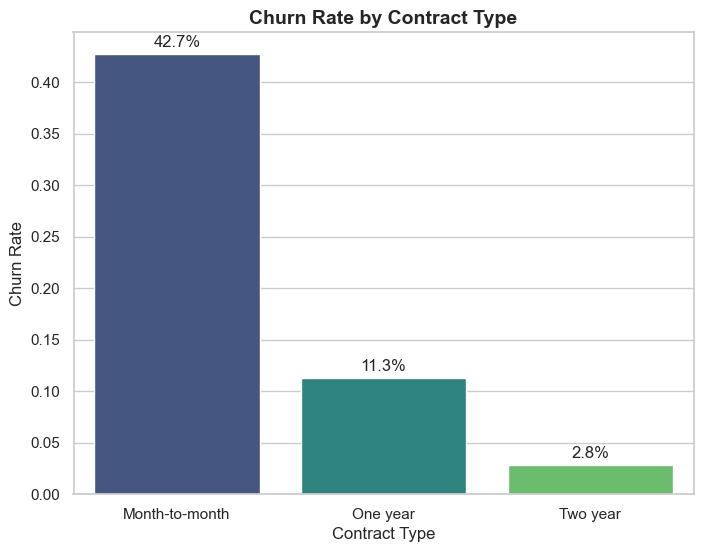

In [40]:
#Churn by Contract Type
plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=df,
    x='Contract',
    y='Churn_Numeric',
    errorbar=None,
    palette='viridis'
)
plt.title('Churn Rate by Contract Type',fontsize=14,fontweight='bold')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%',
        (p.get_x()+p.get_width()/2.0,p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,3),
        textcoords='offset points'
    )
plt.show()

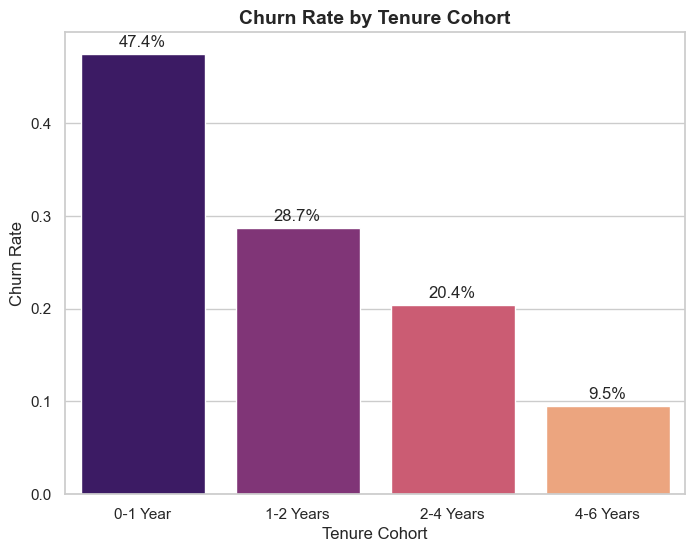

In [64]:
#Tenure Cohort Categorization
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[-1,12,24,48,72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)
plt.figure(figsize=(8,6))
ax2 = sns.barplot(
    data = df,
    x='Tenure_Group',
    y='Churn_Numeric',
    errorbar=None,
    palette='magma',
)
plt.title('Churn Rate by Tenure Cohort',fontsize=14,fontweight='bold')
plt.ylabel('Churn Rate')
plt.xlabel('Tenure Cohort')
for p in ax2.patches:
    ax2.annotate(
        f'{p.get_height()*100:.1f}%',
        (p.get_x()+p.get_width()/2.0,p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,3),
        textcoords='offset points'
    )
plt.show()

In [69]:
# Suppress all runtime warning messages to ensure clean output during notebook and script execution.
warnings.filterwarnings('ignore',category=FutureWarning)

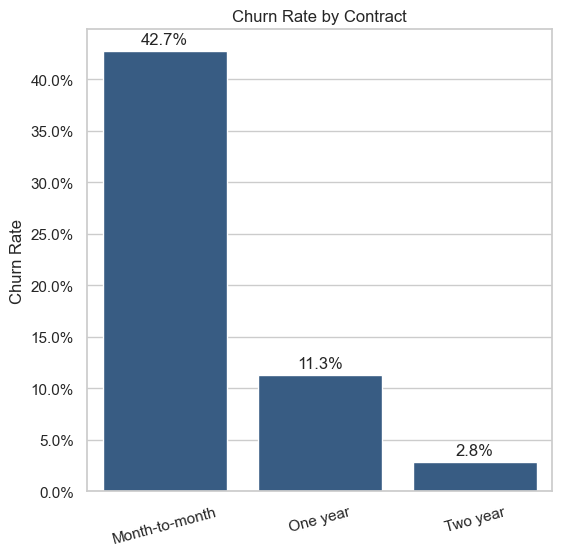

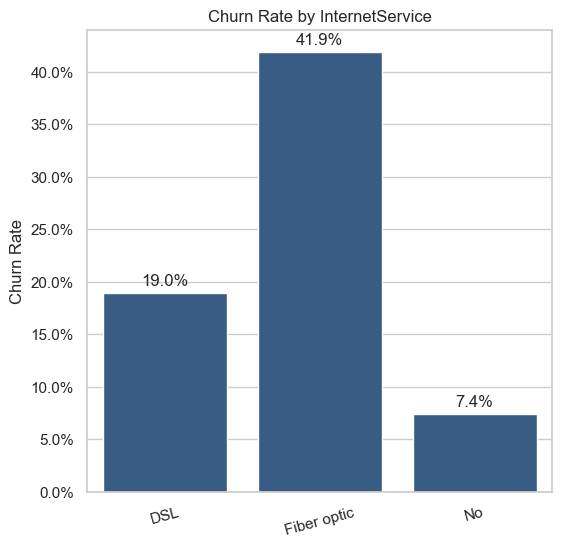

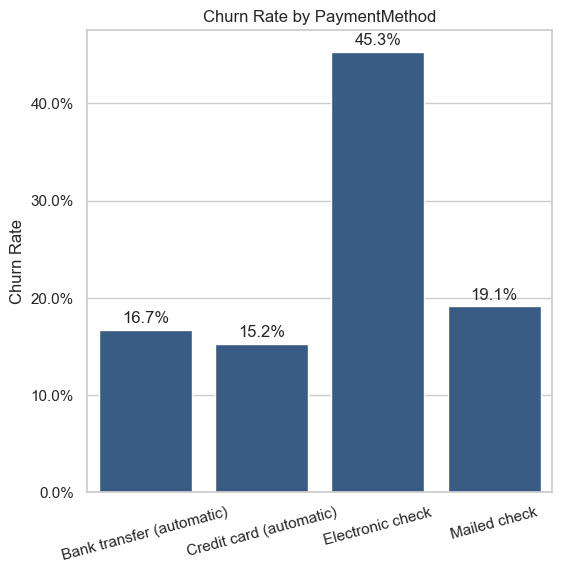

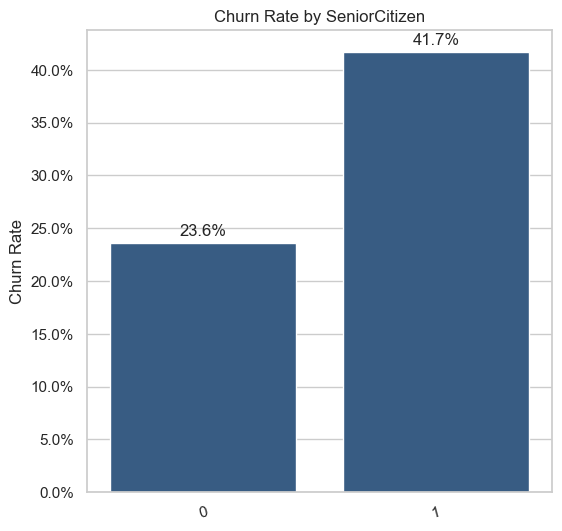

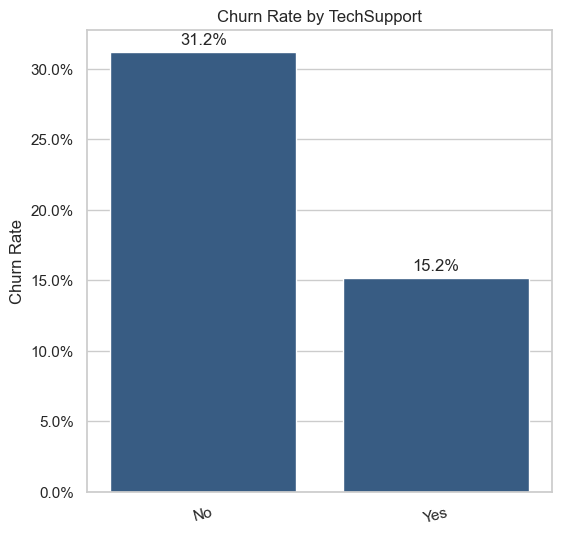

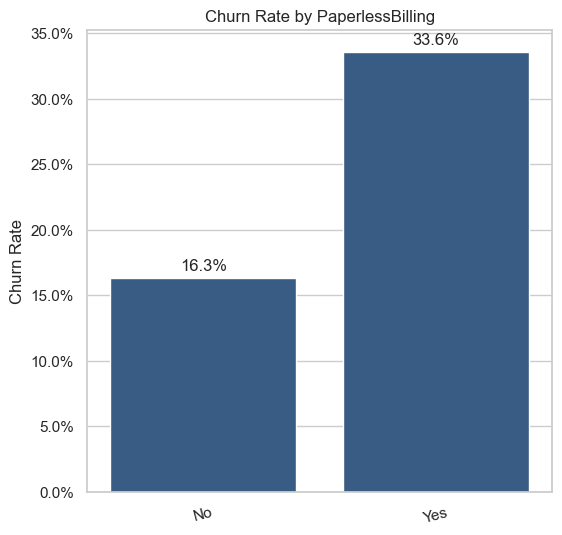

In [71]:
# Key features to analyze
key_features = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'TechSupport', 'PaperlessBilling']
# Loop through features and plot each churn rate separately
for col in key_features:
    plt.figure(figsize=(6,6))
    # Calculate average churn rate for each category
    churn_data = df.groupby(col)['Churn_Numeric'].mean().reset_index()
    # Create simple bar chart
    ax = sns.barplot(data=churn_data,x=col,y='Churn_Numeric',color='#2b5c8f')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    # Iterate through each bar patch in the axes to 
    #calculate, format, and position percentage labels above the bars
    for p in ax.patches:
     ax.annotate(
        f'{p.get_height()*100:.1f}%',
        (p.get_x() + p.get_width()/2.0, p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
     )
    # Add title and labels
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.xlabel('')
    plt.xticks(rotation=15)
    plt.show()

In [74]:
df.to_csv('Telco Customer Churn.csv',index=False)

<h1 style="text-align:center;font-weight:bold">I think the data is clean now and ready to build the Streamlit dashboard.</h1>
<h2 style="text-align:center">Note: cleaning was scoped to columns relevant to this analysis; some minor inconsistencies may remain outside that scope.</h2>